In [1]:
import pandas as pd
file_path = r"/home/onyxia/work/PROJET_STATAPP_MILLIMAN/Génération de données synthétiques/Fraud Detection Dataset.csv"

data = pd.read_csv(file_path)
data.head()


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


Utilisation de Ollama

In [2]:
import os
import json
import re
import time
import urllib3
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# 1. CONFIGURATION API
# ─────────────────────────────────────────────

OLLAMA_API_URL = "https://ollama-api.lab.groupe-genes.fr/api/generate"
MODEL_NAME = "mistral" #llama3.3"   

# True = désactive la vérification SSL 
SKIP_SSL_VERIFY = True

# Nombre de tentatives si le modèle est en cours de chargement
MAX_RETRIES_LOAD = 2
RETRY_DELAY_SECONDS = 2

if SKIP_SSL_VERIFY:
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)



In [3]:

# ─────────────────────────────────────────────
# 2. ANALYSE STATISTIQUE DU DATASET (ENRICHIE)
# ─────────────────────────────────────────────
def construire_resume_donnees(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:
    """Construit un résumé enrichi du dataset pour le LLM."""
    
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    data_filtree = data.drop(columns=colonnes_exclues, errors="ignore")
    parties_resume = []

    # Infos de base
    if "Fraudulent" in data_filtree.columns:
        taux_fraude = data_filtree["Fraudulent"].mean() * 100
        nb_frauds = int(data_filtree["Fraudulent"].sum())
        parties_resume.append(f"Dataset: {data.shape[0]} lignes, taux fraude: {taux_fraude:.1f}% ({nb_frauds} cas)")
    
    # VARIABLES QUANTITATIVES 
    colonnes_num = data_filtree.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
    
    if len(colonnes_num) > 0:
        parties_resume.append(f"\n VARIABLES QUANTITATIVES :")
        for col in colonnes_num:
            if col == "Fraudulent":
                continue
            
            # Calcul des statistiques descriptives (moyenne, médiane, écart-type, min, max, quartiles)
            stats = data_filtree[col].describe()
            fraud_mean = data_filtree[data_filtree['Fraudulent'] == 1][col].mean()
            legit_mean = data_filtree[data_filtree['Fraudulent'] == 0][col].mean()
            median_fraud = data_filtree[data_filtree['Fraudulent'] == 1][col].median()
            median_legit = data_filtree[data_filtree['Fraudulent'] == 0][col].median()
            std_fraud = data_filtree[data_filtree['Fraudulent'] == 1][col].std()
            std_legit = data_filtree[data_filtree['Fraudulent'] == 0][col].std()

            parties_resume.append(f"  {col}:")
            parties_resume.append(f"    Moyenne (Fraudes) = {fraud_mean:.2f} | Moyenne (Légitimes) = {legit_mean:.2f}")
            parties_resume.append(f"    Médiane (Fraudes) = {median_fraud:.2f} | Médiane (Légitimes) = {median_legit:.2f}")
            parties_resume.append(f"    Ecart-type (Fraudes) = {std_fraud:.2f} | Ecart-type (Légitimes) = {std_legit:.2f}")
            parties_resume.append(f"    Min: {stats['min']:.2f} | Max: {stats['max']:.2f}")
            parties_resume.append(f"    Quartiles : Q1 = {stats['25%']:.2f}, Q2 = {stats['50%']:.2f}, Q3 = {stats['75%']:.2f}")
            
            print(f"\n{col} - Statistiques détaillées :")
            print(f"  Moyenne (Fraudes) = {fraud_mean:.2f} | Moyenne (Légitimes) = {legit_mean:.2f}")
            print(f"  Médiane (Fraudes) = {median_fraud:.2f} | Médiane (Légitimes) = {median_legit:.2f}")
            print(f"  Ecart-type (Fraudes) = {std_fraud:.2f} | Ecart-type (Légitimes) = {std_legit:.2f}")
            print(f"  Min = {stats['min']:.2f} | Max = {stats['max']:.2f}")
            print(f"  Quartiles : Q1 = {stats['25%']:.2f}, Q2 = {stats['50%']:.2f} (Médiane), Q3 = {stats['75%']:.2f}")

    # VARIABLES QUALITATIVES 
    colonnes_cat = data_filtree.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()
    
    if len(colonnes_cat) > 0:
        parties_resume.append(f"\n VARIABLES QUALITATIVES :")
        for col in colonnes_cat:
            # Calcul du taux de fraude par modalité (top 3) et comptage des catégories
            mode_fraud_rate = data_filtree.groupby(col)['Fraudulent'].mean().sort_values(ascending=False)
            mode_count = data_filtree[col].value_counts()

            parties_resume.append(f"  {col} (taux fraude) : {dict((k, f'{v*100:.0f}%') for k, v in mode_fraud_rate.items())}")
            parties_resume.append(f"  {col} (comptage des modalités) : {dict(mode_count)}")
            
            print(f"\n{col} - Statistiques qualitatives :")
            print(f"  Taux de fraude par modalité : {dict((k, f'{v*100:.0f}%') for k, v in mode_fraud_rate.items())}")
            print(f"  Comptage des modalités : {dict(mode_count)}")

    # Corrélations - TOP 3
    if "Fraudulent" in data_filtree.columns and len(colonnes_num) > 1:
        parties_resume.append(f"\n🔗 TOP CORRÉLATIONS avec Fraudulent :")
        corr = data_filtree[colonnes_num].corr()["Fraudulent"].drop("Fraudulent", errors='ignore')
        top_corr = corr.abs().sort_values(ascending=False).head(3)
        for var in top_corr.index:
            parties_resume.append(f"  {var}: {top_corr[var]:.2f}")
            print(f"\nCorrélation avec Fraudulent pour {var} : {top_corr[var]:.2f}")

    return "\n".join(parties_resume), data_filtree.columns.tolist()


In [4]:

# ─────────────────────────────────────────────
# 3. CONSTRUCTION DU PROMPT 
# ─────────────────────────────────────────────
def construire_prompt_dag_causal(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:

    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    resume_donnees, colonnes_pertinentes = construire_resume_donnees(data, colonnes_exclues)
    liste_colonnes = ", ".join(colonnes_pertinentes)

    #  Prompt  avec exemples
    system_prompt = f"""
Tu es un expert de classe mondiale en inférence causale et détection de fraude bancaire.

 MISSION CRITIQUE : Construire un DAG causal RÉALISTE qui capture la VRAIE structure causale.

 ERREUR FATALE À ÉVITER :
 NE CRÉE PAS un graphe où toutes les variables pointent directement vers Fraudulent !
 C'est une RÉGRESSION, PAS un DAG causal !

 UN VRAI DAG CAUSAL doit avoir :
1. Des variables ROOT (causes premières, sans parents)
   Exemples : Account_Age, Location, Previous_Fraudulent_Transactions
   
2. Des variables INTERMÉDIAIRES (médiateurs/modérateurs)
   Exemples : Account_Age → Number_of_Transactions_Last_24H
              Location → Device_Used
              Time_of_Transaction → Transaction_Amount
   
3. Des CHEMINS CAUSAUX complexes vers Fraudulent
   Exemple : Account_Age → Number_of_Transactions_Last_24H → Fraudulent
              (et NON : Account_Age → Fraudulent directement)

 RÈGLES D'INFÉRENCE CAUSALE :
- Une jeune compte (Account_Age faible) → moins de transactions historiques → comportement suspect
- Le lieu (Location) influence le device utilisé → patterns de fraude
- L'heure (Time_of_Transaction) influence le montant typique → détection anomalies
- L'historique de fraude influence le comportement actuel → montants, fréquence
- Le type de paiement dépend du contexte (device, location) → risque fraude

 STRUCTURE ATTENDUE :
- Variables ROOT : 3-4 variables (Account_Age, Location, Previous_Fraudulent_Transactions, etc.)
- Variables INTERMÉDIAIRES : 4-6 variables influencées ET influençant d'autres
- Variable CIBLE : Fraudulent (influencée par 3-5 variables maximum, pas toutes !)

Variables disponibles : {liste_colonnes}
""".strip()

    user_prompt = f"""
{resume_donnees}

 CONSTRUIS UN DAG CAUSAL RÉALISTE :

ÉTAPE 1 - Identifie les VARIABLES ROOT (qui ne dépendent de rien) :
- Account_Age ? (existe avant toute transaction)
- Location ? (caractéristique externe)
- Previous_Fraudulent_Transactions ? (historique passé)
- Autres ?

ÉTAPE 2 - Identifie les MÉDIATEURS (variables influencées ET qui influencent) :
- Number_of_Transactions_Last_24H dépend de quoi ? (Account_Age ? Previous_Fraudulent_Transactions ?)
- Transaction_Amount dépend de quoi ? (Time_of_Transaction ? Device_Used ? Account_Age ?)
- Device_Used dépend de quoi ? (Location ? Account_Age ?)
- Payment_Method dépend de quoi ? (Location ? Transaction_Amount ?)
- Transaction_Type dépend de quoi ?

ÉTAPE 3 - Quelles variables influencent DIRECTEMENT Fraudulent ?
 NE SÉLECTIONNE QUE 3-5 VARIABLES qui ont un impact DIRECT (pas toutes !)
Exemples :
- Previous_Fraudulent_Transactions → Fraudulent (historique)
- Number_of_Transactions_Last_24H → Fraudulent (comportement récent)
- Transaction_Amount → Fraudulent (montant anormal)
- Device_Used → Fraudulent (device suspect)

 CONTRAINTE ABSOLUE :
- AU MOINS 50% des variables doivent avoir des liens ENTRE ELLES (pas seulement vers Fraudulent)
- Fraudulent doit avoir MAXIMUM 5 parents directs
- Chaque variable intermédiaire doit avoir AU MOINS 1 parent ET 1 enfant

 FORMAT JSON (STRICTEMENT) :
{{
  "noeuds": ["Account_Age", "Location", ..., "Fraudulent"],
  "liens": [
    {{"de": "Account_Age", "vers": "Number_of_Transactions_Last_24H", "raison": "Un compte récent a moins d'historique transactionnel"}},
    {{"de": "Number_of_Transactions_Last_24H", "vers": "Fraudulent", "raison": "Activité anormalement élevée est un signal de fraude"}},
    ...
  ],
  "commentaire_expert": "Ce DAG capture les mécanismes causaux : l'âge du compte influence le comportement transactionnel qui à son tour influence la probabilité de fraude. Les variables contextuelles (location, device) interagissent entre elles avant d'affecter la fraude."
}}

 VÉRIFIE AVANT DE RÉPONDRE :
✓ Y a-t-il des liens ENTRE variables (pas seulement vers Fraudulent) ?
✓ Fraudulent a-t-il MOINS de 6 parents ?
✓ Y a-t-il des chemins causaux multi-étapes ? (ex: A→B→Fraudulent)

RETOURNE UNIQUEMENT LE JSON.
""".strip()

    return system_prompt, user_prompt, colonnes_pertinentes



In [5]:

# ─────────────────────────────────────────────
# 4. APPEL À L'API OLLAMA 
# ─────────────────────────────────────────────
def appeler_api_ollama(system_prompt: str, user_prompt: str, model_name: str = MODEL_NAME) -> str:
    """
    Appelle l'API Ollama en mode /api/generate et retourne le texte généré.
    Gère le cas où le modèle répond d'abord avec done_reason='load'.
    """

    headers = {
        "Content-Type": "application/json"
    }

    prompt_complet = f"{system_prompt}\n\n{user_prompt}"

    #  Paramètres optimisés 
    payload = {
        "model": model_name,
        "prompt": prompt_complet,
        "stream": False,
        "options": {
            "temperature": 0.3,
            "top_p": 0.9,
            "top_k": 40,
            "num_predict": 2000,
        }
    }

    last_result = None

    for tentative in range(1, MAX_RETRIES_LOAD + 2):
        try:
            response = requests.post(
                OLLAMA_API_URL,
                headers=headers,
                json=payload,
                timeout=300,  
                verify=not SKIP_SSL_VERIFY
            )
            response.raise_for_status()

        except requests.exceptions.Timeout:
            print(f" Timeout dépassé (tentative {tentative}/{MAX_RETRIES_LOAD + 1})")
            if tentative < MAX_RETRIES_LOAD + 1:
                print(f" Nouvelle tentative dans {RETRY_DELAY_SECONDS}s...")
                time.sleep(RETRY_DELAY_SECONDS)
                continue
            raise RuntimeError("Timeout persistant : le modèle met trop de temps à répondre")
            
        except requests.exceptions.RequestException as e:
            raise RuntimeError(f"Erreur lors de l'appel API Ollama : {e}")

        try:
            result = response.json()
            last_result = result
        except json.JSONDecodeError:
            raise RuntimeError(f"Réponse API non JSON : {response.text[:1000]}")

        print(f" Tentative {tentative} - réponse reçue ({len(result.get('response', ''))} chars)")

        contenu = result.get("response", "")
        done_reason = result.get("done_reason", "")

        if isinstance(contenu, str) and contenu.strip():
            return contenu.strip()

        if done_reason == "load" and tentative < (MAX_RETRIES_LOAD + 1):
            print(f" Modèle en cours de chargement, nouvelle tentative dans {RETRY_DELAY_SECONDS}s...")
            time.sleep(RETRY_DELAY_SECONDS)
            continue

        break

    raise RuntimeError(
        "Réponse vide ou format inattendu renvoyé par l'API Ollama :\n"
        + json.dumps(last_result, indent=2, ensure_ascii=False)
    )


def interroger_llm_pour_dag(
    data: pd.DataFrame,
    colonnes_exclues: list = None,
    model_name: str = MODEL_NAME
) -> dict:
    """Envoie le prompt au LLM via API et retourne le DAG parsé."""

    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    system_prompt, user_prompt, colonnes_pertinentes = construire_prompt_dag_causal(data, colonnes_exclues)

    print(" Interrogation du LLM via API Ollama pour le DAG causal...")
    print(f" Modèle utilisé : {model_name}")
    print(f" Vérification SSL : {'désactivée' if SKIP_SSL_VERIFY else 'activée'}")
    print(f" Analyse de {len(colonnes_pertinentes)} variables pertinentes (exclus : {', '.join(colonnes_exclues)})\n")

    sortie_brute = appeler_api_ollama(system_prompt, user_prompt, model_name=model_name)
    
    print("\n" + "="*70)
    print(" RÉPONSE COMPLÈTE DU LLM :")
    print("="*70)
    print(sortie_brute)
    print("="*70 + "\n")

    dag_data = extraire_json_reponse(sortie_brute)

    #  Validation et nettoyage du DAG
    dag_data = valider_et_nettoyer_dag(dag_data, colonnes_pertinentes)

    return dag_data



In [6]:

# ─────────────────────────────────────────────
# 5. EXTRACTION DU JSON 
# ─────────────────────────────────────────────
def extraire_json_reponse(texte_brut: str) -> dict:
    """Extrait et valide le JSON retourné par le LLM."""

    #  Nettoyage des backticks markdown
    texte_nettoye = texte_brut.strip()
    if texte_nettoye.startswith("```json"):
        texte_nettoye = texte_nettoye[7:]
    if texte_nettoye.startswith("```"):
        texte_nettoye = texte_nettoye[3:]
    if texte_nettoye.endswith("```"):
        texte_nettoye = texte_nettoye[:-3]
    texte_nettoye = texte_nettoye.strip()

    # Stratégie 1 : Parse direct
    try:
        parsed = json.loads(texte_nettoye)
        if _valider_structure_json(parsed):
            print(" JSON extrait (méthode directe)")
            return _normaliser_json(parsed)
    except json.JSONDecodeError:
        pass

    # Stratégie 2 : Regex
    motif_json = r"\{[\s\S]*\}"
    correspondances = re.findall(motif_json, texte_brut)

    for match in correspondances:
        try:
            parsed = json.loads(match)
            if _valider_structure_json(parsed):
                print(" JSON extrait (méthode regex)")
                return _normaliser_json(parsed)
        except json.JSONDecodeError:
            continue

    # Stratégie 3 : Extraction agressive
    debut = texte_brut.find('{')
    fin = texte_brut.rfind('}')
    if debut != -1 and fin != -1 and fin > debut:
        try:
            parsed = json.loads(texte_brut[debut:fin+1])
            if _valider_structure_json(parsed):
                print(" JSON extrait (extraction agressive)")
                return _normaliser_json(parsed)
        except json.JSONDecodeError:
            pass

    print(" Impossible d'extraire un JSON valide.")
    print(" Texte reçu (premiers 1000 chars):")
    print(texte_brut[:1000])
    return {"reponse_brute": texte_brut, "noeuds": [], "liens": []}


def _valider_structure_json(parsed: dict) -> bool:
    """Vérifie que le JSON a la structure attendue."""
    if not isinstance(parsed, dict):
        return False
    has_nodes = "noeuds" in parsed or "nodes" in parsed
    has_edges = "liens" in parsed or "edges" in parsed
    return has_nodes and has_edges


def _normaliser_json(parsed: dict) -> dict:
    """Normalise les clés JSON en français."""
    if "nodes" in parsed:
        parsed["noeuds"] = parsed.pop("nodes")
    if "edges" in parsed:
        parsed["liens"] = parsed.pop("edges")
    
    # Normaliser les liens
    for lien in parsed.get("liens", []):
        if "from" in lien:
            lien["de"] = lien.pop("from")
        if "to" in lien:
            lien["vers"] = lien.pop("to")
        if "reason" in lien:
            lien["raison"] = lien.pop("reason")
    
    return parsed


#  Validation du DAG
def valider_et_nettoyer_dag(dag_data: dict, colonnes_pertinentes: list) -> dict:
    """Valide et nettoie le DAG généré par le LLM."""
    
    if "noeuds" not in dag_data or "liens" not in dag_data:
        return dag_data
    
    # Filtrer les nœuds valides
    noeuds_valides = [n for n in dag_data["noeuds"] if n in colonnes_pertinentes]
    noeuds_invalides = [n for n in dag_data["noeuds"] if n not in colonnes_pertinentes]
    
    if noeuds_invalides:
        print(f" Nœuds invalides ignorés : {noeuds_invalides}")
    
    # Filtrer les liens valides
    liens_valides = [
        lien for lien in dag_data.get("liens", [])
        if lien.get("de") in noeuds_valides and lien.get("vers") in noeuds_valides
    ]
    
    # Vérifier l'acyclicité
    G = nx.DiGraph()
    G.add_edges_from([(l["de"], l["vers"]) for l in liens_valides])
    
    if not nx.is_directed_acyclic_graph(G):
        print(" Cycles détectés, suppression des arêtes problématiques...")
        liens_sans_cycles = []
        G_temp = nx.DiGraph()
        for lien in liens_valides:
            G_temp.add_edge(lien["de"], lien["vers"])
            if nx.is_directed_acyclic_graph(G_temp):
                liens_sans_cycles.append(lien)
            else:
                G_temp.remove_edge(lien["de"], lien["vers"])
        liens_valides = liens_sans_cycles
    
    dag_data["noeuds"] = noeuds_valides
    dag_data["liens"] = liens_valides
    
    print(f" DAG validé : {len(noeuds_valides)} nœuds, {len(liens_valides)} liens")
    
    return dag_data



In [7]:

# ─────────────────────────────────────────────
# 7. VISUALISATION  
# ─────────────────────────────────────────────
def visualiser_dag(dag_data: dict, chemin_sauvegarde: str = "dag_causal_fraude.png"):
    """Visualise le DAG causal avec une mise en page professionnelle."""

    if not dag_data.get("liens"):
        print(" Aucun lien trouvé pour la visualisation.")
        return

    G = nx.DiGraph()
    G.add_nodes_from(dag_data["noeuds"])
    for lien in dag_data["liens"]:
        G.add_edge(lien["de"], lien["vers"], raison=lien.get("raison", ""))

    #   Layout hiérarchique 
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args="-Grankdir=TB -Gnodesep=2.0 -Granksep=3.0")
    except Exception:
        pos = _disposition_par_niveaux(G)

    # Figure 
    fig, ax = plt.subplots(figsize=(24, 16), facecolor='white')
    
    # Titre
    ax.text(0.5, 0.98, "Graphe Causal (DAG) — Détection de Fraude Bancaire", 
            transform=ax.transAxes, fontsize=22, fontweight='bold',
            ha='center', va='top', color='#2c3e50')
    ax.text(0.5, 0.95, "Analyse par LLM", 
            transform=ax.transAxes, fontsize=14, style='italic',
            ha='center', va='top', color='#7f8c8d')

    # Palette 
    couleur_cible = "#c0392b"
    couleur_feature = "#2980b9"
    couleur_edge = "#95a5a6"
    
    couleurs_noeuds = [couleur_cible if n == "Fraudulent" else couleur_feature for n in G.nodes()]
    
    # Nœuds
    nx.draw_networkx_nodes(
        G, pos,
        node_color=couleurs_noeuds,
        node_size=6000,
        alpha=0.95,
        edgecolors='#34495e',
        linewidths=3,
        ax=ax
    )
    
    # Labels avec wrapping
    labels_noeuds = {}
    for noeud in G.nodes():
        if len(noeud) > 18:
            parties = noeud.replace('_', ' ').split()
            if len(parties) > 2:
                labels_noeuds[noeud] = ' '.join(parties[:2]) + '\n' + ' '.join(parties[2:])
            else:
                labels_noeuds[noeud] = noeud.replace('_', '\n', 1)
        else:
            labels_noeuds[noeud] = noeud.replace('_', ' ')
    
    nx.draw_networkx_labels(
        G, pos,
        labels=labels_noeuds,
        font_size=11,
        font_weight='bold',
        font_color='white',
        ax=ax
    )
    
    # Arêtes 
    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        arrowsize=50,              #  Flèches 
        arrowstyle='-|>',          # Style flèche bien visible
        edge_color=couleur_edge,
        width=4.5,                 #  Traits 
        connectionstyle="arc3,rad=0.1",  #  Moins de courbure
        alpha=0.8,                 #  Plus opaque
        node_size=6000,
        min_source_margin=25,      # Marge pour que la flèche parte bien du bord du nœud
        min_target_margin=25,      # Marge pour que la flèche arrive bien au bord
        ax=ax
    )
    
    # Légende
    legende = [
        mpatches.Patch(facecolor=couleur_cible, edgecolor='#34495e', linewidth=2, 
                      label="Variable Cible (Fraudulent)"),
        mpatches.Patch(facecolor=couleur_feature, edgecolor='#34495e', linewidth=2,
                      label="Variables Explicatives"),
    ]
    ax.legend(handles=legende, loc='upper left', fontsize=13, framealpha=0.95, 
             edgecolor='#34495e', fancybox=True, title="Légende", title_fontsize=14)
    
    # Stats
    info_text = f"Nœuds : {len(G.nodes())} | Liens causaux : {len(G.edges())}"
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes,
           fontsize=12, color='#7f8c8d', weight='bold',
           bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                    edgecolor='#bdc3c7', alpha=0.95, linewidth=2))
    
    # Relations top 6
    relations_top = []
    for i, lien in enumerate(dag_data["liens"][:6]):
        relations_top.append(f"{i+1}. {lien['de']} → {lien['vers']}")
    
    if relations_top:
        relations_text = "Relations Causales:\n" + "\n".join(relations_top)
        ax.text(0.98, 0.98, relations_text, transform=ax.transAxes,
               fontsize=10, color='#2c3e50', ha='right', va='top',
               bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1', 
                        edgecolor='#95a5a6', alpha=0.95, linewidth=2),
               family='monospace')
    
    ax.axis('off')
    ax.margins(0.12)
    
    # Export 
    plt.savefig(chemin_sauvegarde, dpi=300, bbox_inches="tight", 
               facecolor='white', pad_inches=0.3)
    
    chemin_svg = chemin_sauvegarde.replace('.png', '.svg')
    plt.savefig(chemin_svg, format='svg', bbox_inches="tight", 
               facecolor='white', pad_inches=0.3)
    
    plt.show()
    print(f"\n DAG sauvegardé (PNG 300 DPI) : {chemin_sauvegarde}")
    print(f" DAG sauvegardé (SVG vectoriel) : {chemin_svg}")


def _disposition_par_niveaux(G):
    """Disposition hiérarchique par niveaux."""
    try:
        niveaux = {}
        for noeud in nx.topological_sort(G):
            preds = list(G.predecessors(noeud))
            niveaux[noeud] = 0 if not preds else max(niveaux[p] for p in preds) + 1
    except:
        return nx.spring_layout(G, k=5, iterations=100, seed=42)
    
    par_niveau = {}
    for noeud, niveau in niveaux.items():
        par_niveau.setdefault(niveau, []).append(noeud)
    
    pos = {}
    max_niveau = max(par_niveau.keys())
    
    for niveau, noeuds in par_niveau.items():
        y = (max_niveau - niveau) * 4
        n = len(noeuds)
        for i, noeud in enumerate(noeuds):
            x = (i - (n - 1) / 2) * 6
            pos[noeud] = (x, y)
    
    return pos



In [8]:

# ─────────────────────────────────────────────
# 8. AFFICHAGE DU RÉSUMÉ
# ─────────────────────────────────────────────
def afficher_resume_dag(dag_data: dict):
    """Affiche un résumé lisible du DAG causal."""

    print("\n" + "=" * 70)
    print(" GRAPHE CAUSAL (DAG) — ANALYSE EXPERT LLM")
    print("=" * 70)

    if "commentaire_expert" in dag_data:
        print(f"\n Commentaire expert :\n   {dag_data['commentaire_expert']}\n")
    elif "expert_comment" in dag_data:
        print(f"\n Commentaire expert :\n   {dag_data['expert_comment']}\n")

    print(f" Nœuds ({len(dag_data.get('noeuds', []))}) :")
    for noeud in dag_data.get("noeuds", []):
        print(f"   • {noeud}")

    print(f"\n Liens causaux ({len(dag_data.get('liens', []))}) :")
    for lien in dag_data.get("liens", []):
        print(f"   {lien['de']:30} → {lien['vers']:30}")
        print(f"      └─ Raison : {lien.get('raison', 'Non spécifiée')}")

    print("=" * 70)



 DÉMARRAGE DE L'INFÉRENCE CAUSALE AVEC LLM VIA API
 Endpoint API : https://ollama-api.lab.groupe-genes.fr/api/generate
 Modèle : mistral
 Vérification SSL désactivée : True
 Colonnes exclues : Transaction_ID, User_ID


Transaction_Amount - Statistiques détaillées :
  Moyenne (Fraudes) = 3118.37 | Moyenne (Légitimes) = 2989.93
  Médiane (Fraudes) = 2516.01 | Médiane (Légitimes) = 2524.39
  Ecart-type (Fraudes) = 5654.75 | Ecart-type (Légitimes) = 5010.29
  Min = 5.03 | Max = 49997.80
  Quartiles : Q1 = 1270.55, Q2 = 2524.10 (Médiane), Q3 = 3787.24

Time_of_Transaction - Statistiques détaillées :
  Moyenne (Fraudes) = 11.70 | Moyenne (Légitimes) = 11.48
  Médiane (Fraudes) = 12.00 | Médiane (Légitimes) = 12.00
  Ecart-type (Fraudes) = 6.98 | Ecart-type (Légitimes) = 6.92
  Min = 0.00 | Max = 23.00
  Quartiles : Q1 = 5.00, Q2 = 12.00 (Médiane), Q3 = 17.00

Previous_Fraudulent_Transactions - Statistiques détaillées :
  Moyenne (Fraudes) = 2.00 | Moyenne (Légitimes) = 2.00
  Médiane (Fraude

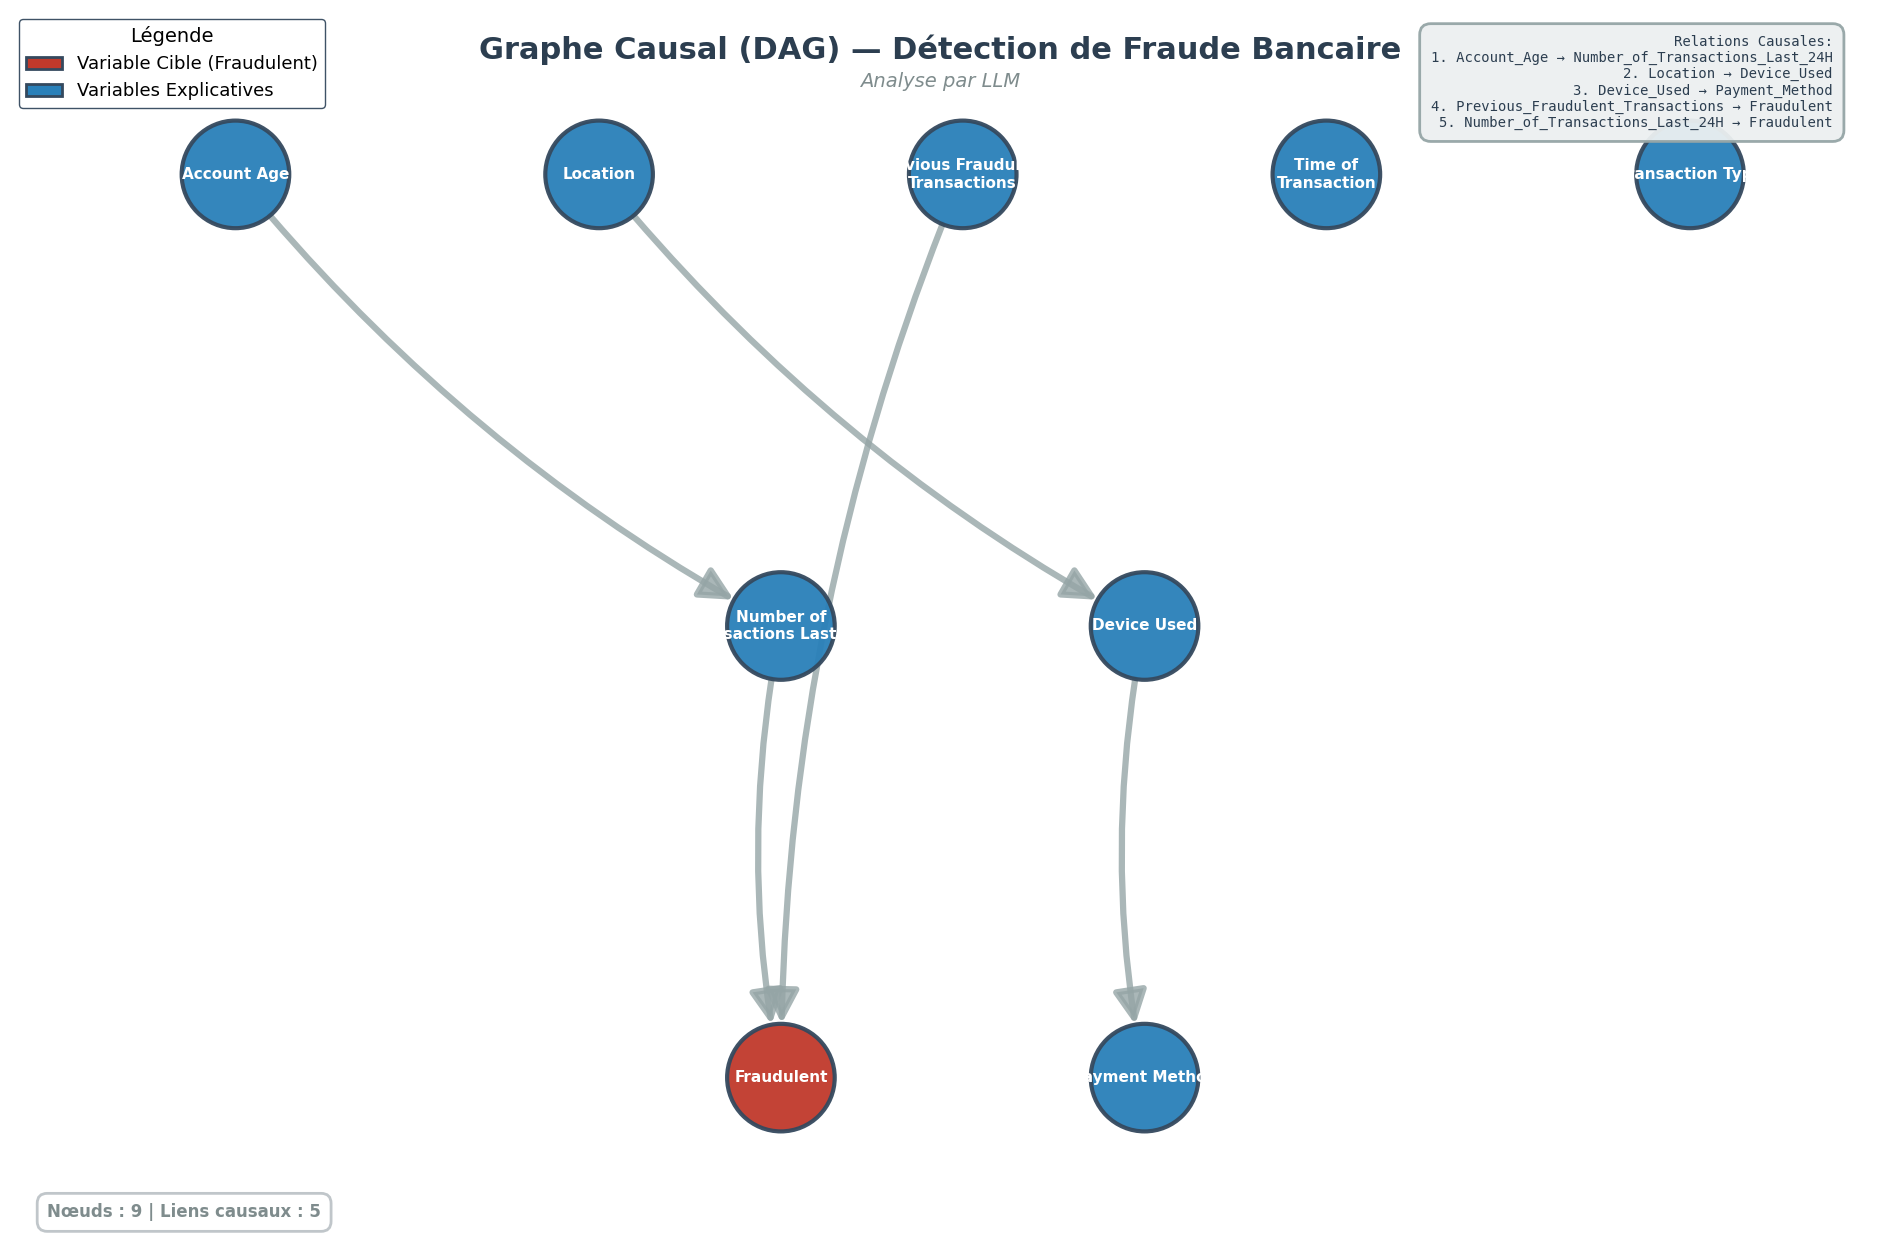


 DAG sauvegardé (PNG 300 DPI) : dag_causal_fraude.png
 DAG sauvegardé (SVG vectoriel) : dag_causal_fraude.svg


In [9]:

# ─────────────────────────────────────────────
# 9. PIPELINE PRINCIPAL
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # data = pd.read_csv("mon_dataset.csv")

    COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]

    print("=" * 70)
    print(" DÉMARRAGE DE L'INFÉRENCE CAUSALE AVEC LLM VIA API")
    print("=" * 70)
    print(f" Endpoint API : {OLLAMA_API_URL}")
    print(f" Modèle : {MODEL_NAME}")
    print(f" Vérification SSL désactivée : {SKIP_SSL_VERIFY}")
    print(f" Colonnes exclues : {', '.join(COLONNES_EXCLUES)}\n")

    # Générer le DAG 
    dag_data = interroger_llm_pour_dag(
        data,
        colonnes_exclues=COLONNES_EXCLUES,
        model_name=MODEL_NAME
    )

    afficher_resume_dag(dag_data)
    visualiser_dag(dag_data, chemin_sauvegarde="dag_causal_fraude.png")

    with open("dag_causal_fraude.json", "w", encoding="utf-8") as f:
        json.dump(dag_data, f, indent=2, ensure_ascii=False)


# Test d'independances